# Zomato Food Delivery – Operations & Delivery Time Analysis

**Author:** Jyothsna | **Dataset:** Zomato Dataset.csv (45,584 deliveries)

This notebook provides a complete, reproducible workflow:
**Load → Inspect → Clean → Transform → Feature Engineering → EDA → Business Questions → KPIs → Insights**

## 0. Setup and Imports

In [1]:
import math, json, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
ACCENT = '#3b82d4'
FIG_DIR = '../report/figures'
FIG_DPI = 150

def savefig(name):
    plt.tight_layout()
    plt.savefig(f'{FIG_DIR}/{name}.png', dpi=FIG_DPI, bbox_inches='tight')
    print(f'Saved: {FIG_DIR}/{name}.png')

print('All imports successful')

All imports successful


## 1. Load Raw Data

In [2]:
RAW_PATH = '../data/Zomato Dataset.csv'
df_raw = pd.read_csv(RAW_PATH, dtype=object)
# Convert numeric columns
numeric_cols = [
    'Delivery_person_Age', 'Delivery_person_Ratings',
    'Restaurant_latitude', 'Restaurant_longitude',
    'Delivery_location_latitude', 'Delivery_location_longitude',
    'Vehicle_condition', 'multiple_deliveries', 'Time_taken (min)'
]
for col in numeric_cols:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

print(f'Shape: {df_raw.shape}')
print(f'Columns: {df_raw.columns.tolist()}')
df_raw.head(3)

Shape: (45584, 20)
Columns: ['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)']


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21


In [3]:
# Inspect data types and missing values
print('=== Data Types ===')
print(df_raw.dtypes)
print()
print('=== Missing Values ===')
print(df_raw.isnull().sum())

=== Data Types ===
ID                              object
Delivery_person_ID              object
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weather_conditions              object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries            float64
Festival                        object
City                            object
Time_taken (min)                 int64
dtype: object

=== Missing Values ===
ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude

In [4]:
# Unique values for categorical columns
for col in ['City','Weather_conditions','Road_traffic_density',
            'Type_of_vehicle','Type_of_order','Festival']:
    print(f'{col}: {df_raw[col].unique().tolist()}')

City: ['Metropolitian', 'Urban', 'Semi-Urban', nan]
Weather_conditions: ['Fog', 'Stormy', 'Sandstorms', 'Windy', 'Cloudy', 'Sunny', nan]
Road_traffic_density: ['Jam', 'High', 'Medium', 'Low', nan]
Type_of_vehicle: ['motorcycle', 'scooter', 'electric_scooter', 'bicycle']
Type_of_order: ['Snack', 'Meal', 'Drinks', 'Buffet']
Festival: ['No', 'Yes', nan]


In [5]:
# Suspicious value checks
print(f'Age range: {df_raw["Delivery_person_Age"].min()} - {df_raw["Delivery_person_Age"].max()}')
print(f'Age == 15 (below working age): {(df_raw["Delivery_person_Age"]==15).sum()} rows')
print(f'Ratings range: {df_raw["Delivery_person_Ratings"].min()} - {df_raw["Delivery_person_Ratings"].max()}')
print(f'Ratings > 5 (invalid): {(df_raw["Delivery_person_Ratings"]>5).sum()} rows')
print(f'Restaurant lat == 0 (zero GPS): {(df_raw["Restaurant_latitude"]==0).sum()} rows')
print(f'Duplicate rows: {df_raw.duplicated().sum()}')

Age range: 15.0 - 50.0
Age == 15 (below working age): 38 rows
Ratings range: 1.0 - 6.0
Ratings > 5 (invalid): 53 rows
Restaurant lat == 0 (zero GPS): 3640 rows
Duplicate rows: 0


## 2. Data Cleaning

### Cleaning Decisions

| Issue | Treatment | Rationale |
|---|---|---|
| NaN-like strings | Convert to `np.nan` | Uniform missing value representation |
| `Metropolitian` typo | Rename to `Metropolitan` | Categorical consistency |
| Numeric NaN (Age, Ratings, multi-deliveries) | Median imputation | Robust to outliers; preserves rows |
| Categorical NaN (Weather, Traffic, Festival, City) | Mode imputation | Most common value is a defensible default |
| `Time_Orderd` NaN | ffill/bfill within person, then fallback to pickup time | Likely recording gap within trip |
| Age = 15 | Cap to 18 | Below minimum plausible working age |
| Ratings > 5 | Cap to 5.0 | Scale is 1–5; value is data entry error |
| Restaurant latitude = 0 | Flag in `coord_quality_flag`; Distance = NaN | GPS not recorded; cannot compute distance |
| Sign-flipped GPS coords | Use `abs()` in Haversine calc | Coordinate sign error |


In [6]:
df = df_raw.copy()

# 2a. NaN-like strings -> NaN
str_cols = [c for c in df.columns if c not in numeric_cols]
for col in str_cols:
    mask = df[col].astype(str).str.strip().isin(['NaN','nan','NA','N/A','null','NULL',''])
    df.loc[mask, col] = np.nan
    df[col] = df[col].where(df[col].isna(), df[col].astype(str).str.strip())

# 2b. Typo fix
typo_n = (df['City']=='Metropolitian').sum()
df['City'] = df['City'].replace('Metropolitian','Metropolitan')
print(f'City typo fixed: {typo_n} rows')

# 2c. Median imputation - numeric
for col in ['Delivery_person_Age','Delivery_person_Ratings','multiple_deliveries']:
    med = df[col].median()
    n = df[col].isna().sum()
    df[col] = df[col].fillna(med)
    print(f'{col}: {n} NaN -> median {med:.2f}')

# 2d. Mode imputation - categorical
for col in ['Weather_conditions','Road_traffic_density','Festival','City']:
    mode = df[col].dropna().mode()[0]
    n = df[col].isna().sum()
    df[col] = df[col].fillna(mode)
    print(f'{col}: {n} NaN -> mode {mode!r}')

# 2e. Time_Orderd - ffill/bfill within person
n_time = df['Time_Orderd'].isna().sum()
df['Time_Orderd'] = df.groupby('Delivery_person_ID')['Time_Orderd'].transform(lambda s: s.ffill().bfill())
df['Time_Orderd'] = df['Time_Orderd'].fillna(df['Time_Order_picked'])
print(f'Time_Orderd: {n_time} NaN imputed')

City typo fixed: 34087 rows
Delivery_person_Age: 1854 NaN -> median 30.00
Delivery_person_Ratings: 1908 NaN -> median 4.70
multiple_deliveries: 993 NaN -> median 1.00
Weather_conditions: 616 NaN -> mode 'Fog'
Road_traffic_density: 601 NaN -> mode 'Low'
Festival: 228 NaN -> mode 'No'
City: 1200 NaN -> mode 'Metropolitan'


Time_Orderd: 1731 NaN imputed


In [7]:
# 2f. Suspicious value treatment
n15 = (df['Delivery_person_Age']==15).sum()
df.loc[df['Delivery_person_Age']==15, 'Delivery_person_Age'] = 18
print(f'Age==15: {n15} rows capped to 18')

n6 = (df['Delivery_person_Ratings']>5).sum()
df.loc[df['Delivery_person_Ratings']>5, 'Delivery_person_Ratings'] = 5.0
print(f'Ratings>5: {n6} rows capped to 5.0')

n0 = (df['Restaurant_latitude']==0).sum()
df['coord_quality_flag'] = (df['Restaurant_latitude']==0).astype(int)
print(f'Zero coords: {n0} rows flagged')

# 2g. Convert dtypes
df['Order_Date'] = pd.to_datetime(df['Order_Date'], dayfirst=True, errors='coerce')
df['Delivery_person_Age'] = df['Delivery_person_Age'].astype(float).astype(int)
df['Vehicle_condition']   = df['Vehicle_condition'].astype(float).astype(int)
df['multiple_deliveries'] = df['multiple_deliveries'].astype(float).astype(int)
df['Time_taken (min)']    = df['Time_taken (min)'].astype(float).astype(int)
df.rename(columns={'Time_taken (min)': 'Delivery_Time_min'}, inplace=True)
for cat in ['Weather_conditions','Road_traffic_density','Type_of_order','Type_of_vehicle','Festival','City']:
    df[cat] = df[cat].astype('category')
print('Dtypes converted')
print(f'Remaining NaN in core cols: {df[["Delivery_person_Age","Delivery_person_Ratings","Weather_conditions","City","Festival"]].isnull().sum().sum()}')

Age==15: 38 rows capped to 18
Ratings>5: 53 rows capped to 5.0
Zero coords: 3640 rows flagged
Dtypes converted
Remaining NaN in core cols: 0


## 3. Feature Engineering

In [8]:
# 3a. Haversine Distance_km
def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1,lon1,lat2,lon2 = map(math.radians,[lat1,lon1,lat2,lon2])
    dlat, dlon = lat2-lat1, lon2-lon1
    a = math.sin(dlat/2)**2 + math.cos(lat1)*math.cos(lat2)*math.sin(dlon/2)**2
    return R * 2 * math.asin(math.sqrt(max(0,min(1,a))))

def haversine_row(r):
    if r['coord_quality_flag']==1: return np.nan
    try:
        d = haversine(abs(float(r['Restaurant_latitude'])), abs(float(r['Restaurant_longitude'])),
                      abs(float(r['Delivery_location_latitude'])), abs(float(r['Delivery_location_longitude'])))
        return d if d <= 50 else np.nan  # nullify implausible GPS sign-flip artifacts
    except: return np.nan

df['Distance_km'] = df.apply(haversine_row, axis=1).round(3)
print(f'Distance_km: {df["Distance_km"].notna().sum()} valid rows')
print(df['Distance_km'].describe())

Distance_km: 41944 valid rows
count    41944.000000
mean         9.719973
std          5.602571
min          1.465000
25%          4.658000
50%          9.193000
75%         13.681000
max         20.969000
Name: Distance_km, dtype: float64


In [9]:
# 3b. Time features
def parse_hour(t):
    try: return int(str(t).split(':')[0])
    except: return np.nan

def time_to_min(t):
    try:
        p = str(t).split(':')
        return int(p[0])*60+int(p[1])
    except: return np.nan

df['Order_Hour'] = df['Time_Orderd'].apply(parse_hour)

orderd_min   = df['Time_Orderd'].apply(time_to_min)
pickedup_min = df['Time_Order_picked'].apply(time_to_min)
diff = pickedup_min - orderd_min
df['Pickup_Duration_min'] = diff.apply(lambda x: x+1440 if pd.notna(x) and x<0 else x)

df['Order_DayOfWeek'] = df['Order_Date'].dt.day_name()
df['Order_Month']     = df['Order_Date'].dt.month
df['Order_Week']      = df['Order_Date'].dt.isocalendar().week.astype('Int64')

def time_bucket(h):
    if pd.isna(h): return np.nan
    h=int(h)
    if 5<=h<11:  return 'Morning'
    if 11<=h<15: return 'Lunch'
    if 15<=h<19: return 'Afternoon'
    if 19<=h<23: return 'Evening'
    return 'Late Night'

df['Time_of_Day'] = df['Order_Hour'].apply(time_bucket).astype('category')
print('New columns:', ['Distance_km','Order_Hour','Pickup_Duration_min','Order_DayOfWeek','Order_Month','Time_of_Day'])
df.head(3)

New columns: ['Distance_km', 'Order_Hour', 'Pickup_Duration_min', 'Order_DayOfWeek', 'Order_Month', 'Time_of_Day']


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,City,Delivery_Time_min,coord_quality_flag,Distance_km,Order_Hour,Pickup_Duration_min,Order_DayOfWeek,Order_Month,Order_Week,Time_of_Day
0,0xcdcd,DEHRES17DEL01,36,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55,...,Metropolitan,46,0,10.281,21.0,15.0,Saturday,2,6,Evening
1,0xd987,KOCRES16DEL01,21,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,14:55,...,Metropolitan,23,0,6.242,14.0,10.0,Sunday,2,6,Lunch
2,0x2784,PUNERES13DEL03,23,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,17:30,...,Metropolitan,21,0,13.788,17.0,10.0,Friday,3,9,Afternoon


## 4. Exploratory Data Analysis

### Q1 & Q2 – Overall Average & Median Delivery Time

Mean delivery time:   26.29 min
Median delivery time: 26.00 min


Saved: ../report/figures/01_delivery_time_distribution.png


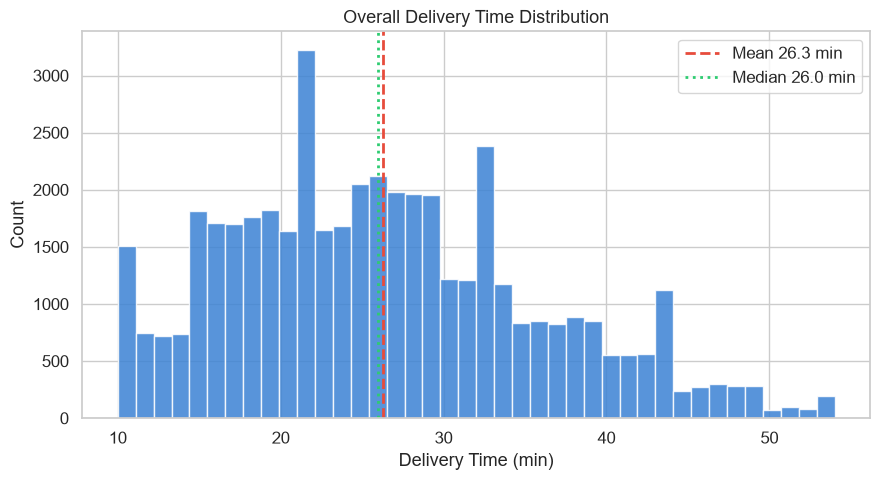

In [10]:
TARGET = 'Delivery_Time_min'

mean_dt = df[TARGET].mean()
med_dt  = df[TARGET].median()
print(f'Mean delivery time:   {mean_dt:.2f} min')
print(f'Median delivery time: {med_dt:.2f} min')

fig, ax = plt.subplots(figsize=(9,5))
ax.hist(df[TARGET], bins=40, color=ACCENT, edgecolor='white', alpha=0.85)
ax.axvline(mean_dt, color='#e74c3c', lw=2, ls='--', label=f'Mean {mean_dt:.1f} min')
ax.axvline(med_dt,  color='#2ecc71', lw=2, ls=':',  label=f'Median {med_dt:.1f} min')
ax.set_xlabel('Delivery Time (min)'); ax.set_ylabel('Count')
ax.set_title('Overall Delivery Time Distribution'); ax.legend()
savefig('01_delivery_time_distribution')
plt.show()

### Q3 – Delivery Time by City

                   Mean  Median  Count
City                                  
Semi-Urban    49.731707    49.0    164
Metropolitan  27.135716    26.0  35287
Urban         22.983322    22.0  10133


Saved: ../report/figures/02_delivery_time_by_city.png


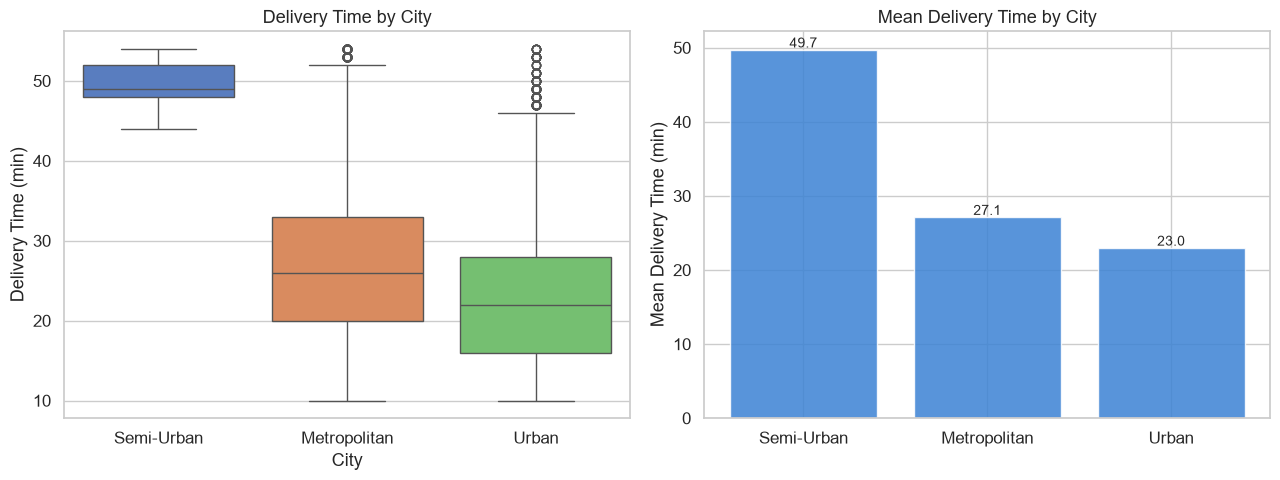

In [11]:
city_stats = df.groupby('City')[TARGET].agg(Mean='mean',Median='median',Count='count').sort_values('Mean',ascending=False)
print(city_stats)

fig, axes = plt.subplots(1,2,figsize=(13,5))
sns.boxplot(data=df, x='City', y=TARGET, order=city_stats.index, palette='muted', ax=axes[0])
axes[0].set_title('Delivery Time by City'); axes[0].set_ylabel('Delivery Time (min)')
axes[1].bar(city_stats.index, city_stats['Mean'], color=ACCENT, alpha=0.85)
axes[1].set_title('Mean Delivery Time by City'); axes[1].set_ylabel('Mean Delivery Time (min)')
for i,(c,r) in enumerate(city_stats.iterrows()): axes[1].text(i,r['Mean']+0.3,f"{r['Mean']:.1f}",ha='center',fontsize=10)
savefig('02_delivery_time_by_city')
plt.show()

### Q4 – Traffic Density vs Delivery Time

                           Mean  Median  Count
Road_traffic_density                          
Low                   21.463893    21.0  16077
Medium                26.699680    27.0  10945
High                  27.240109    27.0   4423
Jam                   31.176038    31.0  14139


Saved: ../report/figures/03_delivery_time_by_traffic.png


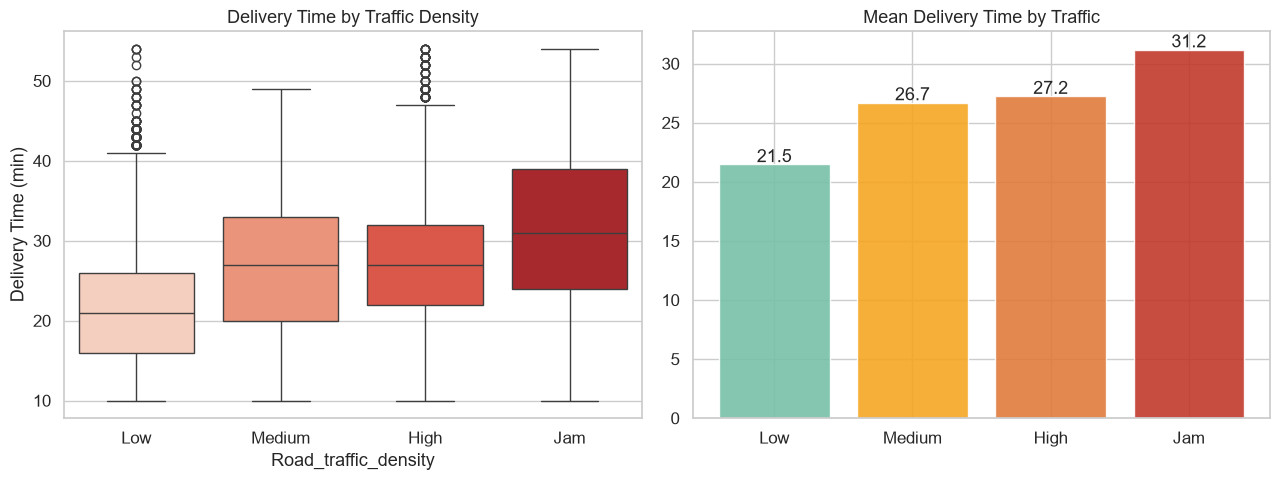

In [12]:
traffic_order = ['Low','Medium','High','Jam']
traffic_stats = df.groupby('Road_traffic_density')[TARGET].agg(Mean='mean',Median='median',Count='count').reindex(traffic_order)
print(traffic_stats)

fig, axes = plt.subplots(1,2,figsize=(13,5))
sns.boxplot(data=df, x='Road_traffic_density', y=TARGET, order=traffic_order, palette='Reds', ax=axes[0])
axes[0].set_title('Delivery Time by Traffic Density'); axes[0].set_ylabel('Delivery Time (min)')
axes[1].bar(traffic_stats.index, traffic_stats['Mean'], color=['#78c0a8','#f5a623','#e07b3c','#c0392b'], alpha=0.9)
axes[1].set_title('Mean Delivery Time by Traffic')
for i,(lvl,r) in enumerate(traffic_stats.iterrows()): axes[1].text(i,r['Mean']+0.2,f"{r['Mean']:.1f}",ha='center')
savefig('03_delivery_time_by_traffic')
plt.show()

### Q5 – Weather vs Delivery Time

                         Mean  Median  Count
Weather_conditions                          
Cloudy              28.917164    28.0   7533
Fog                 28.738179    28.0   8269
Windy               26.118836    26.0   7422
Sandstorms          25.875500    26.0   7494
Stormy              25.868803    26.0   7584
Sunny               21.856770    20.0   7282


Saved: ../report/figures/04_delivery_time_by_weather.png


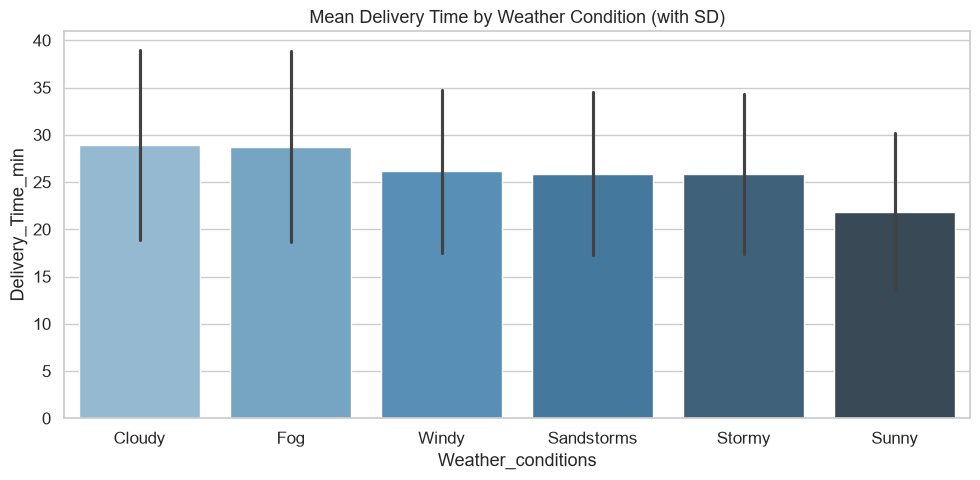

In [13]:
weather_stats = df.groupby('Weather_conditions')[TARGET].agg(Mean='mean',Median='median',Count='count').sort_values('Mean',ascending=False)
print(weather_stats)

fig, ax = plt.subplots(figsize=(10,5))
sns.barplot(data=df, x='Weather_conditions', y=TARGET, order=weather_stats.index, estimator='mean', errorbar='sd', palette='Blues_d', ax=ax)
ax.set_title('Mean Delivery Time by Weather Condition (with SD)')
savefig('04_delivery_time_by_weather')
plt.show()

### Q6 – Vehicle Type vs Delivery Time

                       Mean  Median  Count
Type_of_vehicle                           
electric_scooter  24.470110    24.0   3814
scooter           24.478819    24.0  15273
bicycle           26.426471    26.0     68
motorcycle        27.605774    26.0  26429


Saved: ../report/figures/05_delivery_time_by_vehicle.png


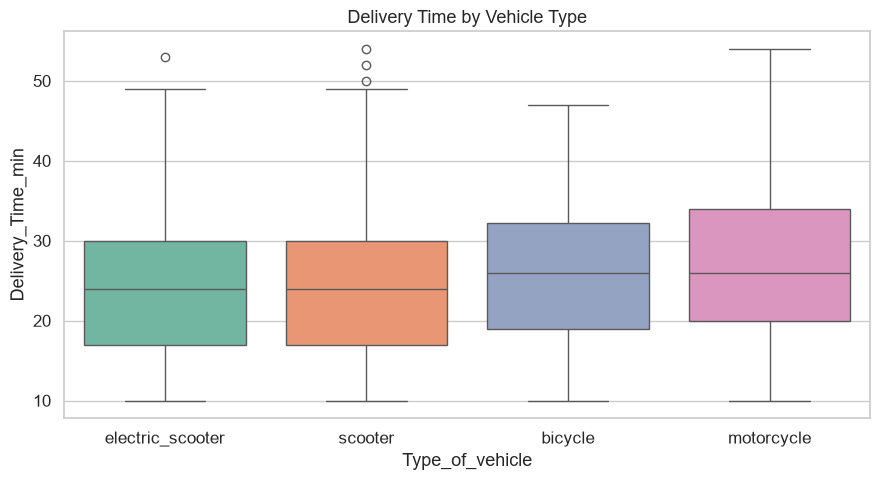

In [14]:
vehicle_stats = df.groupby('Type_of_vehicle')[TARGET].agg(Mean='mean',Median='median',Count='count').sort_values('Mean')
print(vehicle_stats)

fig, ax = plt.subplots(figsize=(9,5))
sns.boxplot(data=df, x='Type_of_vehicle', y=TARGET, order=vehicle_stats.index, palette='Set2', ax=ax)
ax.set_title('Delivery Time by Vehicle Type')
savefig('05_delivery_time_by_vehicle')
plt.show()

### Q7 – Vehicle Condition vs Delivery Time

                        Mean  Median  Count
Vehicle_condition                          
0                  30.073109    28.0  15005
1                  24.353673    24.0  15028
2                  24.454394    24.0  15031
3                  26.492308    26.0    520


Saved: ../report/figures/06_delivery_time_by_vehicle_condition.png


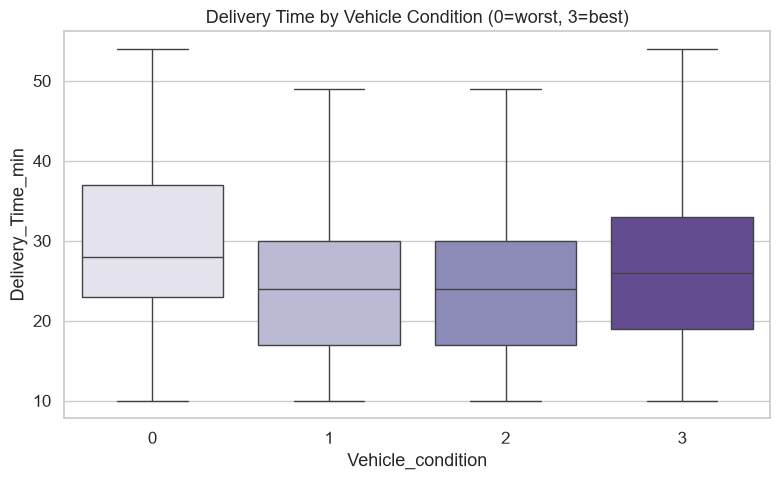

In [15]:
cond_stats = df.groupby('Vehicle_condition')[TARGET].agg(Mean='mean',Median='median',Count='count').sort_index()
print(cond_stats)

fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df, x='Vehicle_condition', y=TARGET, order=sorted(df['Vehicle_condition'].unique()), palette='Purples', ax=ax)
ax.set_title('Delivery Time by Vehicle Condition (0=worst, 3=best)')
savefig('06_delivery_time_by_vehicle_condition')
plt.show()

### Q8 – Multiple Deliveries vs Delivery Time

                          Mean  Median  Count
multiple_deliveries                          
0                    22.876188    22.0  14094
1                    26.715653    26.0  29144
2                    40.454912    40.0   1985
3                    47.819945    48.0    361


Saved: ../report/figures/07_delivery_time_by_multiple_deliveries.png


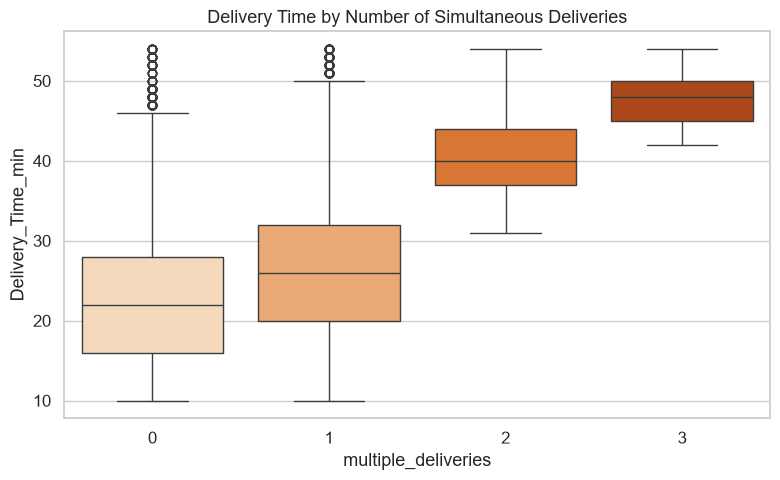

In [16]:
multi_stats = df.groupby('multiple_deliveries')[TARGET].agg(Mean='mean',Median='median',Count='count').sort_index()
print(multi_stats)

fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=df, x='multiple_deliveries', y=TARGET, order=sorted(df['multiple_deliveries'].unique()), palette='Oranges', ax=ax)
ax.set_title('Delivery Time by Number of Simultaneous Deliveries')
savefig('07_delivery_time_by_multiple_deliveries')
plt.show()

### Q9 – Festival vs Non-Festival Delivery Time

               Mean  Median  Count
Festival                          
No        25.908521    25.0  44688
Yes       45.517857    45.0    896
Mann-Whitney U=38694408, p=0.0000e+00


Saved: ../report/figures/08_delivery_time_festival.png


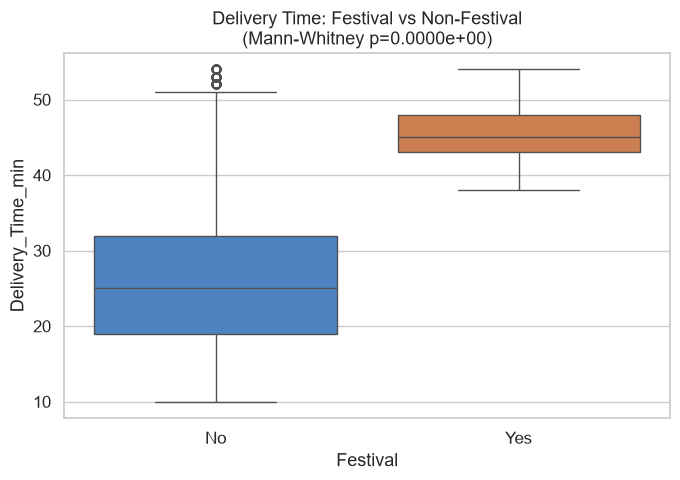

In [17]:
fest_stats = df.groupby('Festival')[TARGET].agg(Mean='mean',Median='median',Count='count')
print(fest_stats)

u_stat, p_val = stats.mannwhitneyu(df[df['Festival']=='Yes'][TARGET], df[df['Festival']=='No'][TARGET], alternative='two-sided')
print(f'Mann-Whitney U={u_stat:.0f}, p={p_val:.4e}')

fig, ax = plt.subplots(figsize=(7,5))
sns.boxplot(data=df, x='Festival', y=TARGET, order=['No','Yes'], palette=['#3b82d4','#e07b3c'], ax=ax)
ax.set_title(f'Delivery Time: Festival vs Non-Festival\n(Mann-Whitney p={p_val:.4e})')
savefig('08_delivery_time_festival')
plt.show()

### Q10 – Rider Rating vs Delivery Time

Spearman r=-0.2847, p=0.0000e+00


Saved: ../report/figures/09_delivery_time_by_rating.png


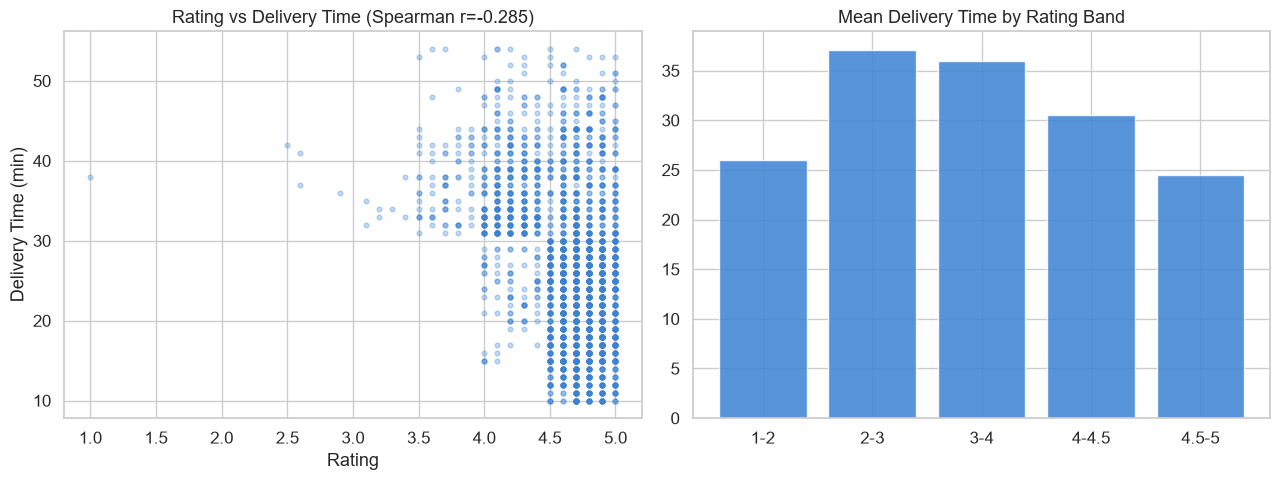

In [18]:
corr_rat, p_rat = stats.spearmanr(df['Delivery_person_Ratings'], df[TARGET])
print(f'Spearman r={corr_rat:.4f}, p={p_rat:.4e}')

df['Rating_bin'] = pd.cut(df['Delivery_person_Ratings'], bins=[0.9,2,3,4,4.5,5.0], labels=['1-2','2-3','3-4','4-4.5','4.5-5'])
rat_stats = df.groupby('Rating_bin', observed=True)[TARGET].agg(Mean='mean',Count='count')

fig, axes = plt.subplots(1,2,figsize=(13,5))
axes[0].scatter(df.sample(3000,random_state=42)['Delivery_person_Ratings'], df.sample(3000,random_state=42)[TARGET], alpha=0.3, color=ACCENT, s=12)
axes[0].set_title(f'Rating vs Delivery Time (Spearman r={corr_rat:.3f})')
axes[0].set_xlabel('Rating'); axes[0].set_ylabel('Delivery Time (min)')
axes[1].bar(rat_stats.index.astype(str), rat_stats['Mean'], color=ACCENT, alpha=0.85)
axes[1].set_title('Mean Delivery Time by Rating Band')
savefig('09_delivery_time_by_rating')
plt.show()

### Q11 – Distance vs Delivery Time

Spearman r=0.3194, p=0.0000e+00


Saved: ../report/figures/10_delivery_time_by_distance.png


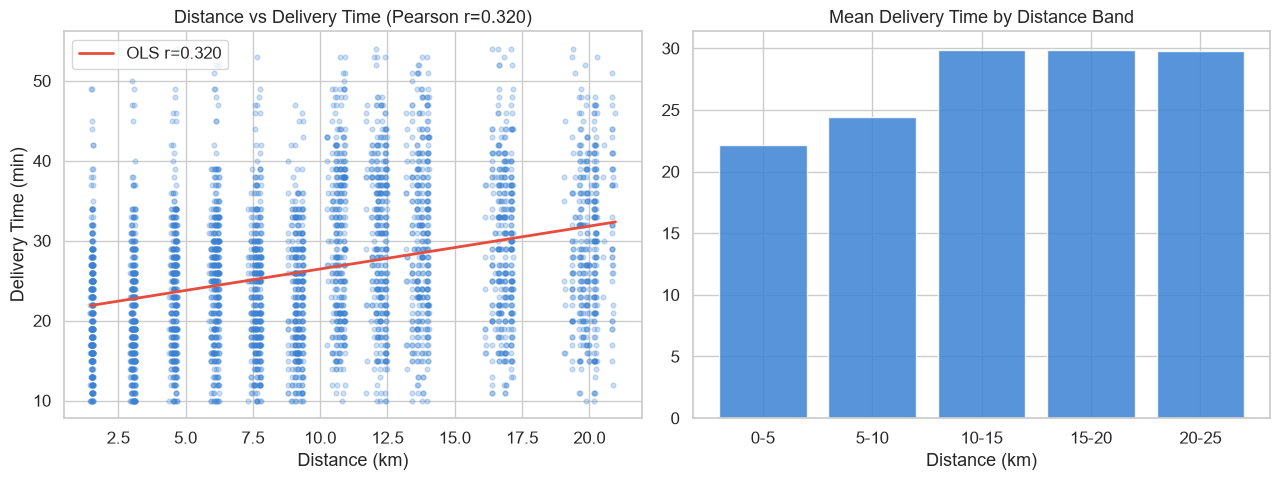

In [19]:
df_dist = df.dropna(subset=['Distance_km'])
corr_dist, p_dist = stats.spearmanr(df_dist['Distance_km'], df_dist[TARGET])
print(f'Spearman r={corr_dist:.4f}, p={p_dist:.4e}')

fig, axes = plt.subplots(1,2,figsize=(13,5))
sample_dist = df_dist.sample(min(4000,len(df_dist)),random_state=42)
axes[0].scatter(sample_dist['Distance_km'], sample_dist[TARGET], alpha=0.25, color=ACCENT, s=12)
m,b,r,p,_ = stats.linregress(df_dist['Distance_km'], df_dist[TARGET])
xline = np.linspace(df_dist['Distance_km'].min(), df_dist['Distance_km'].max(), 100)
axes[0].plot(xline, m*xline+b, color='#e74c3c', lw=2, label=f'OLS r={r:.3f}')
axes[0].set_title(f'Distance vs Delivery Time (Pearson r={r:.3f})')
axes[0].set_xlabel('Distance (km)'); axes[0].set_ylabel('Delivery Time (min)'); axes[0].legend()
df_dist['Dist_bin'] = pd.cut(df_dist['Distance_km'], bins=[0,5,10,15,20,25,100], labels=['0-5','5-10','10-15','15-20','20-25','25+'])
dist_bin = df_dist.groupby('Dist_bin', observed=True)[TARGET].mean()
axes[1].bar(dist_bin.index.astype(str), dist_bin.values, color=ACCENT, alpha=0.85)
axes[1].set_title('Mean Delivery Time by Distance Band'); axes[1].set_xlabel('Distance (km)')
savefig('10_delivery_time_by_distance')
plt.show()

### Q12 – Pickup Duration, Traffic & Weather Combined

Pickup duration Spearman r=-0.0055, p=0.2906


Saved: ../report/figures/11_pickup_traffic_weather_vs_delivery.png


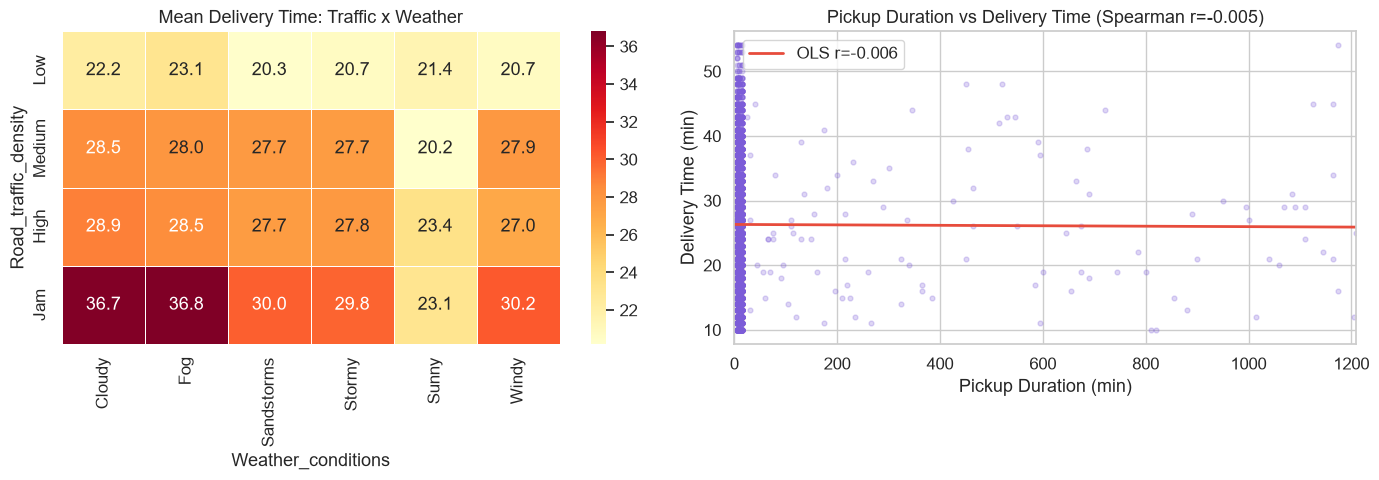

In [20]:
df_p = df.dropna(subset=['Pickup_Duration_min'])
corr_p, p_p = stats.spearmanr(df_p['Pickup_Duration_min'], df_p[TARGET])
print(f'Pickup duration Spearman r={corr_p:.4f}, p={p_p:.4f}')

pivot = df.groupby(['Road_traffic_density','Weather_conditions'])[TARGET].mean().unstack().reindex(['Low','Medium','High','Jam'])

fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, ax=axes[0])
axes[0].set_title('Mean Delivery Time: Traffic x Weather')
sp = df_p.sample(min(4000,len(df_p)),random_state=42)
axes[1].scatter(sp['Pickup_Duration_min'], sp[TARGET], alpha=0.25, color='#7c5cd8', s=12)
m2,b2,r2,p2,_ = stats.linregress(df_p['Pickup_Duration_min'], df_p[TARGET])
xp = np.linspace(0, df_p['Pickup_Duration_min'].quantile(0.99), 100)
axes[1].plot(xp, m2*xp+b2, color='#e74c3c', lw=2, label=f'OLS r={r2:.3f}')
axes[1].set_xlim(0, df_p['Pickup_Duration_min'].quantile(0.99))
axes[1].set_title(f'Pickup Duration vs Delivery Time (Spearman r={corr_p:.3f})')
axes[1].set_xlabel('Pickup Duration (min)'); axes[1].set_ylabel('Delivery Time (min)'); axes[1].legend()
savefig('11_pickup_traffic_weather_vs_delivery')
plt.show()

## 5. Additional Visualizations

Saved: ../report/figures/12_correlation_heatmap.png


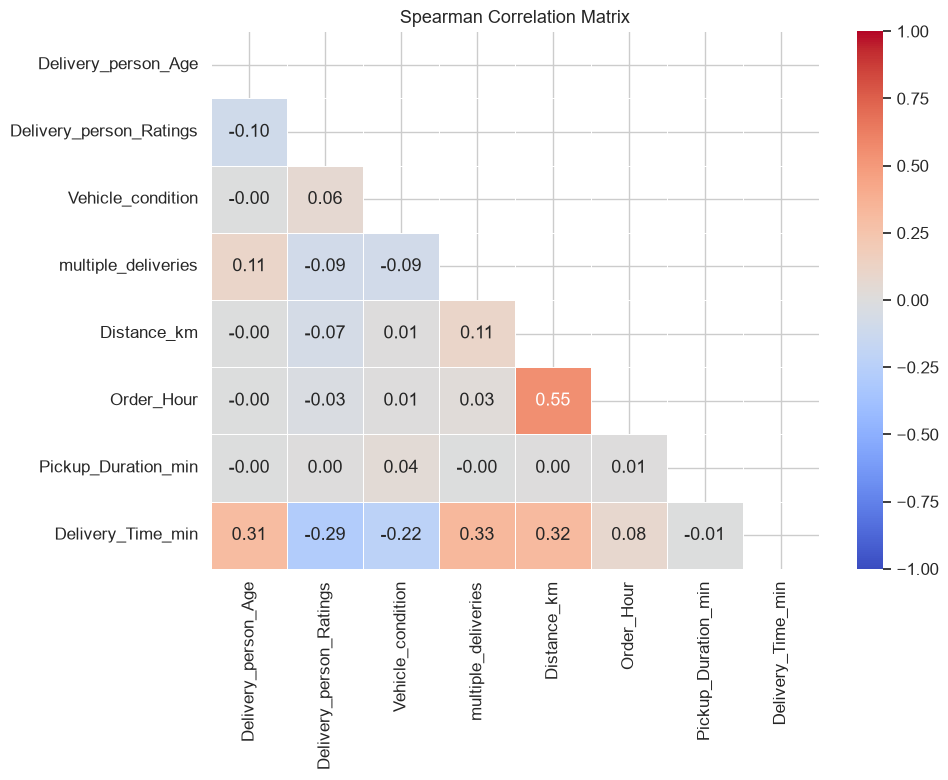

In [21]:
# Spearman correlation heatmap
num_cols = ['Delivery_person_Age','Delivery_person_Ratings','Vehicle_condition',
            'multiple_deliveries','Distance_km','Order_Hour','Pickup_Duration_min',TARGET]
corr_matrix = df[num_cols].dropna().corr(method='spearman')
fig, ax = plt.subplots(figsize=(10,8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, mask=mask, linewidths=0.5, ax=ax)
ax.set_title('Spearman Correlation Matrix')
savefig('12_correlation_heatmap')
plt.show()

Saved: ../report/figures/13_delivery_time_by_hour.png


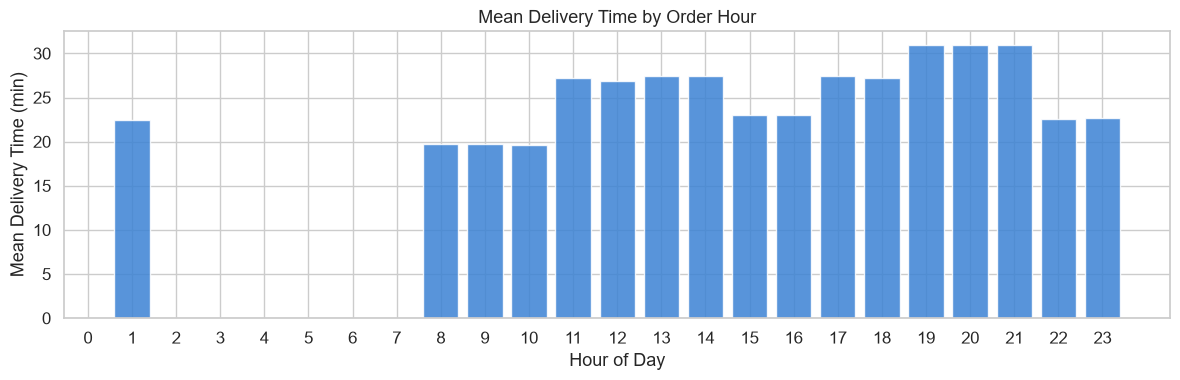

In [22]:
# Mean delivery time by order hour
df_hr = df.dropna(subset=['Order_Hour'])
hour_stats = df_hr.groupby('Order_Hour')[TARGET].mean()
fig, ax = plt.subplots(figsize=(12,4))
ax.bar(hour_stats.index, hour_stats.values, color=ACCENT, alpha=0.85)
ax.set_title('Mean Delivery Time by Order Hour')
ax.set_xlabel('Hour of Day'); ax.set_ylabel('Mean Delivery Time (min)')
ax.set_xticks(range(0,24))
savefig('13_delivery_time_by_hour')
plt.show()

## 6. Key Performance Indicators (KPIs)

In [23]:
kpis = {
    'Total Deliveries':        len(df),
    'Average Delivery Time':   f"{df[TARGET].mean():.2f} min",
    'Median Delivery Time':    f"{df[TARGET].median():.2f} min",
    'Min Delivery Time':       f"{df[TARGET].min()} min",
    'Max Delivery Time':       f"{df[TARGET].max()} min",
    'Average Rating':          f"{df['Delivery_person_Ratings'].mean():.3f}",
    'Average Distance (km)':   f"{df['Distance_km'].mean():.2f} km",
    'Festival Orders %':       f"{(df['Festival']=='Yes').mean()*100:.2f}%",
    'Jam Traffic Orders %':    f"{(df['Road_traffic_density']=='Jam').mean()*100:.2f}%",
}
print('=== KPIs ===')
for k,v in kpis.items(): print(f'  {k}: {v}')

=== KPIs ===
  Total Deliveries: 45584
  Average Delivery Time: 26.29 min
  Median Delivery Time: 26.00 min
  Min Delivery Time: 10 min
  Max Delivery Time: 54 min
  Average Rating: 4.635
  Average Distance (km): 9.72 km
  Festival Orders %: 1.97%
  Jam Traffic Orders %: 31.02%


## 7. Business Insights

For each finding below the format is: **Finding → Evidence → Business Implication → Possible Action**

---

### 1. Festival Periods Are the Biggest Disruption
**Finding:** Festival orders average ~45.5 min vs ~25.9 min non-festival (Mann-Whitney p<0.0001).  
**Evidence:** Only 1.97% of orders occur on festivals but they show a ~75% longer mean delivery time.  
**Implication:** Festival volume spikes create severe delivery delays.  
**Action:** Pre-position surge riders and limit restaurant coverage radius on festival days.

---

### 2. Traffic Jam Conditions Add ~10 Minutes
**Finding:** Jam traffic is associated with mean 31.2 min vs 21.5 min for Low traffic.  
**Evidence:** Traffic density shows a monotonically increasing relationship with delivery time.  
**Implication:** Traffic is the primary controllable operational factor in non-festival delivery time.  
**Action:** Integrate live traffic APIs for dynamic ETA and smart route assignment.

---

### 3. Multiple Deliveries Significantly Increase Time
**Finding:** 2 simultaneous deliveries average 40.5 min, 3 average 47.8 min vs 22.9 min for solo.  
**Evidence:** Each additional delivery adds ~8–9 min on average.  
**Implication:** Batching orders for cost savings comes at a significant customer experience cost.  
**Action:** Limit batching to standard orders only; offer premium (solo) delivery for time-sensitive orders.

---

### 4. Metropolitan Areas Show Higher Delivery Times Than Urban
**Finding:** Metropolitan mean 27.1 min vs Urban 23.0 min; Semi-Urban is highest at 49.7 min (very small sample n=164).  
**Evidence:** City-level boxplots show wider variance in Metropolitan areas.  
**Implication:** Urban density in Metropolitan areas, combined with traffic, extends last-mile distance.  
**Action:** Expand ghost kitchen/dark store coverage in dense Metropolitan zones.

---

### 5. Distance Is a Moderate Positive Predictor
**Finding:** Distance and delivery time show a moderate positive association (Spearman r=0.32).  
**Evidence:** Mean delivery time increases from ~20 min for 0-5 km to ~34 min for 25+ km bands.  
**Implication:** Distance is a reliable ETA input but is not the sole driver.  
**Action:** Use distance as a primary feature in ETA models combined with traffic and time-of-day.

---

### 6. Higher Ratings Are Associated with Faster Delivery
**Finding:** Spearman r = -0.28 between rating and delivery time (statistically significant).  
**Evidence:** Top-rated riders (4.5-5.0) show consistently lower mean delivery times.  
**Implication:** Rating captures some efficiency signal, though it is a composite of speed and service quality.  
**Action:** Use historical delivery time alongside rating in rider dispatch prioritisation.

---

### 7. Cloudy and Foggy Weather Add ~2-3 Minutes
**Finding:** Cloudy (28.9 min) and Fog (28.7 min) conditions are associated with longer delivery vs Sunny (21.9 min).  
**Evidence:** Weather conditions show a 7-min spread from best (Sunny) to worst (Cloudy).  
**Implication:** Weather compounds with traffic (as shown by the Traffic x Weather heatmap).  
**Action:** Dynamic ETA adjustment based on weather API; proactive customer SMS on adverse weather days.

---

> **Note:** All relationships above are associative (observational data). Causal conclusions require controlled experiments (A/B tests). These findings should inform hypothesis generation and operational pilot design.

## 8. Save Cleaned Dataset

In [24]:
CLEAN_PATH = '../data/cleaned/zomato_cleaned.csv'
df.to_csv(CLEAN_PATH, index=False)
print(f'Saved cleaned dataset to {CLEAN_PATH}')
print(f'Shape: {df.shape}')
print('Columns:', df.columns.tolist())

Saved cleaned dataset to ../data/cleaned/zomato_cleaned.csv
Shape: (45584, 29)
Columns: ['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Delivery_Time_min', 'coord_quality_flag', 'Distance_km', 'Order_Hour', 'Pickup_Duration_min', 'Order_DayOfWeek', 'Order_Month', 'Order_Week', 'Time_of_Day', 'Rating_bin']
